In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.datasets import load_diabetes
from scipy import stats

# Cargar el conjunto de datos
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


In [4]:
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [5]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [7]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [8]:
df['sex'].unique()

array([ 0.05068012, -0.04464164])

Comenten que medidas relevantes vieron: cosas que les llamaron la atención de esta salida. Por cada variable.

In [9]:
# Estadísticas descriptivas
descriptive_stats = df.describe()
print(descriptive_stats)


                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

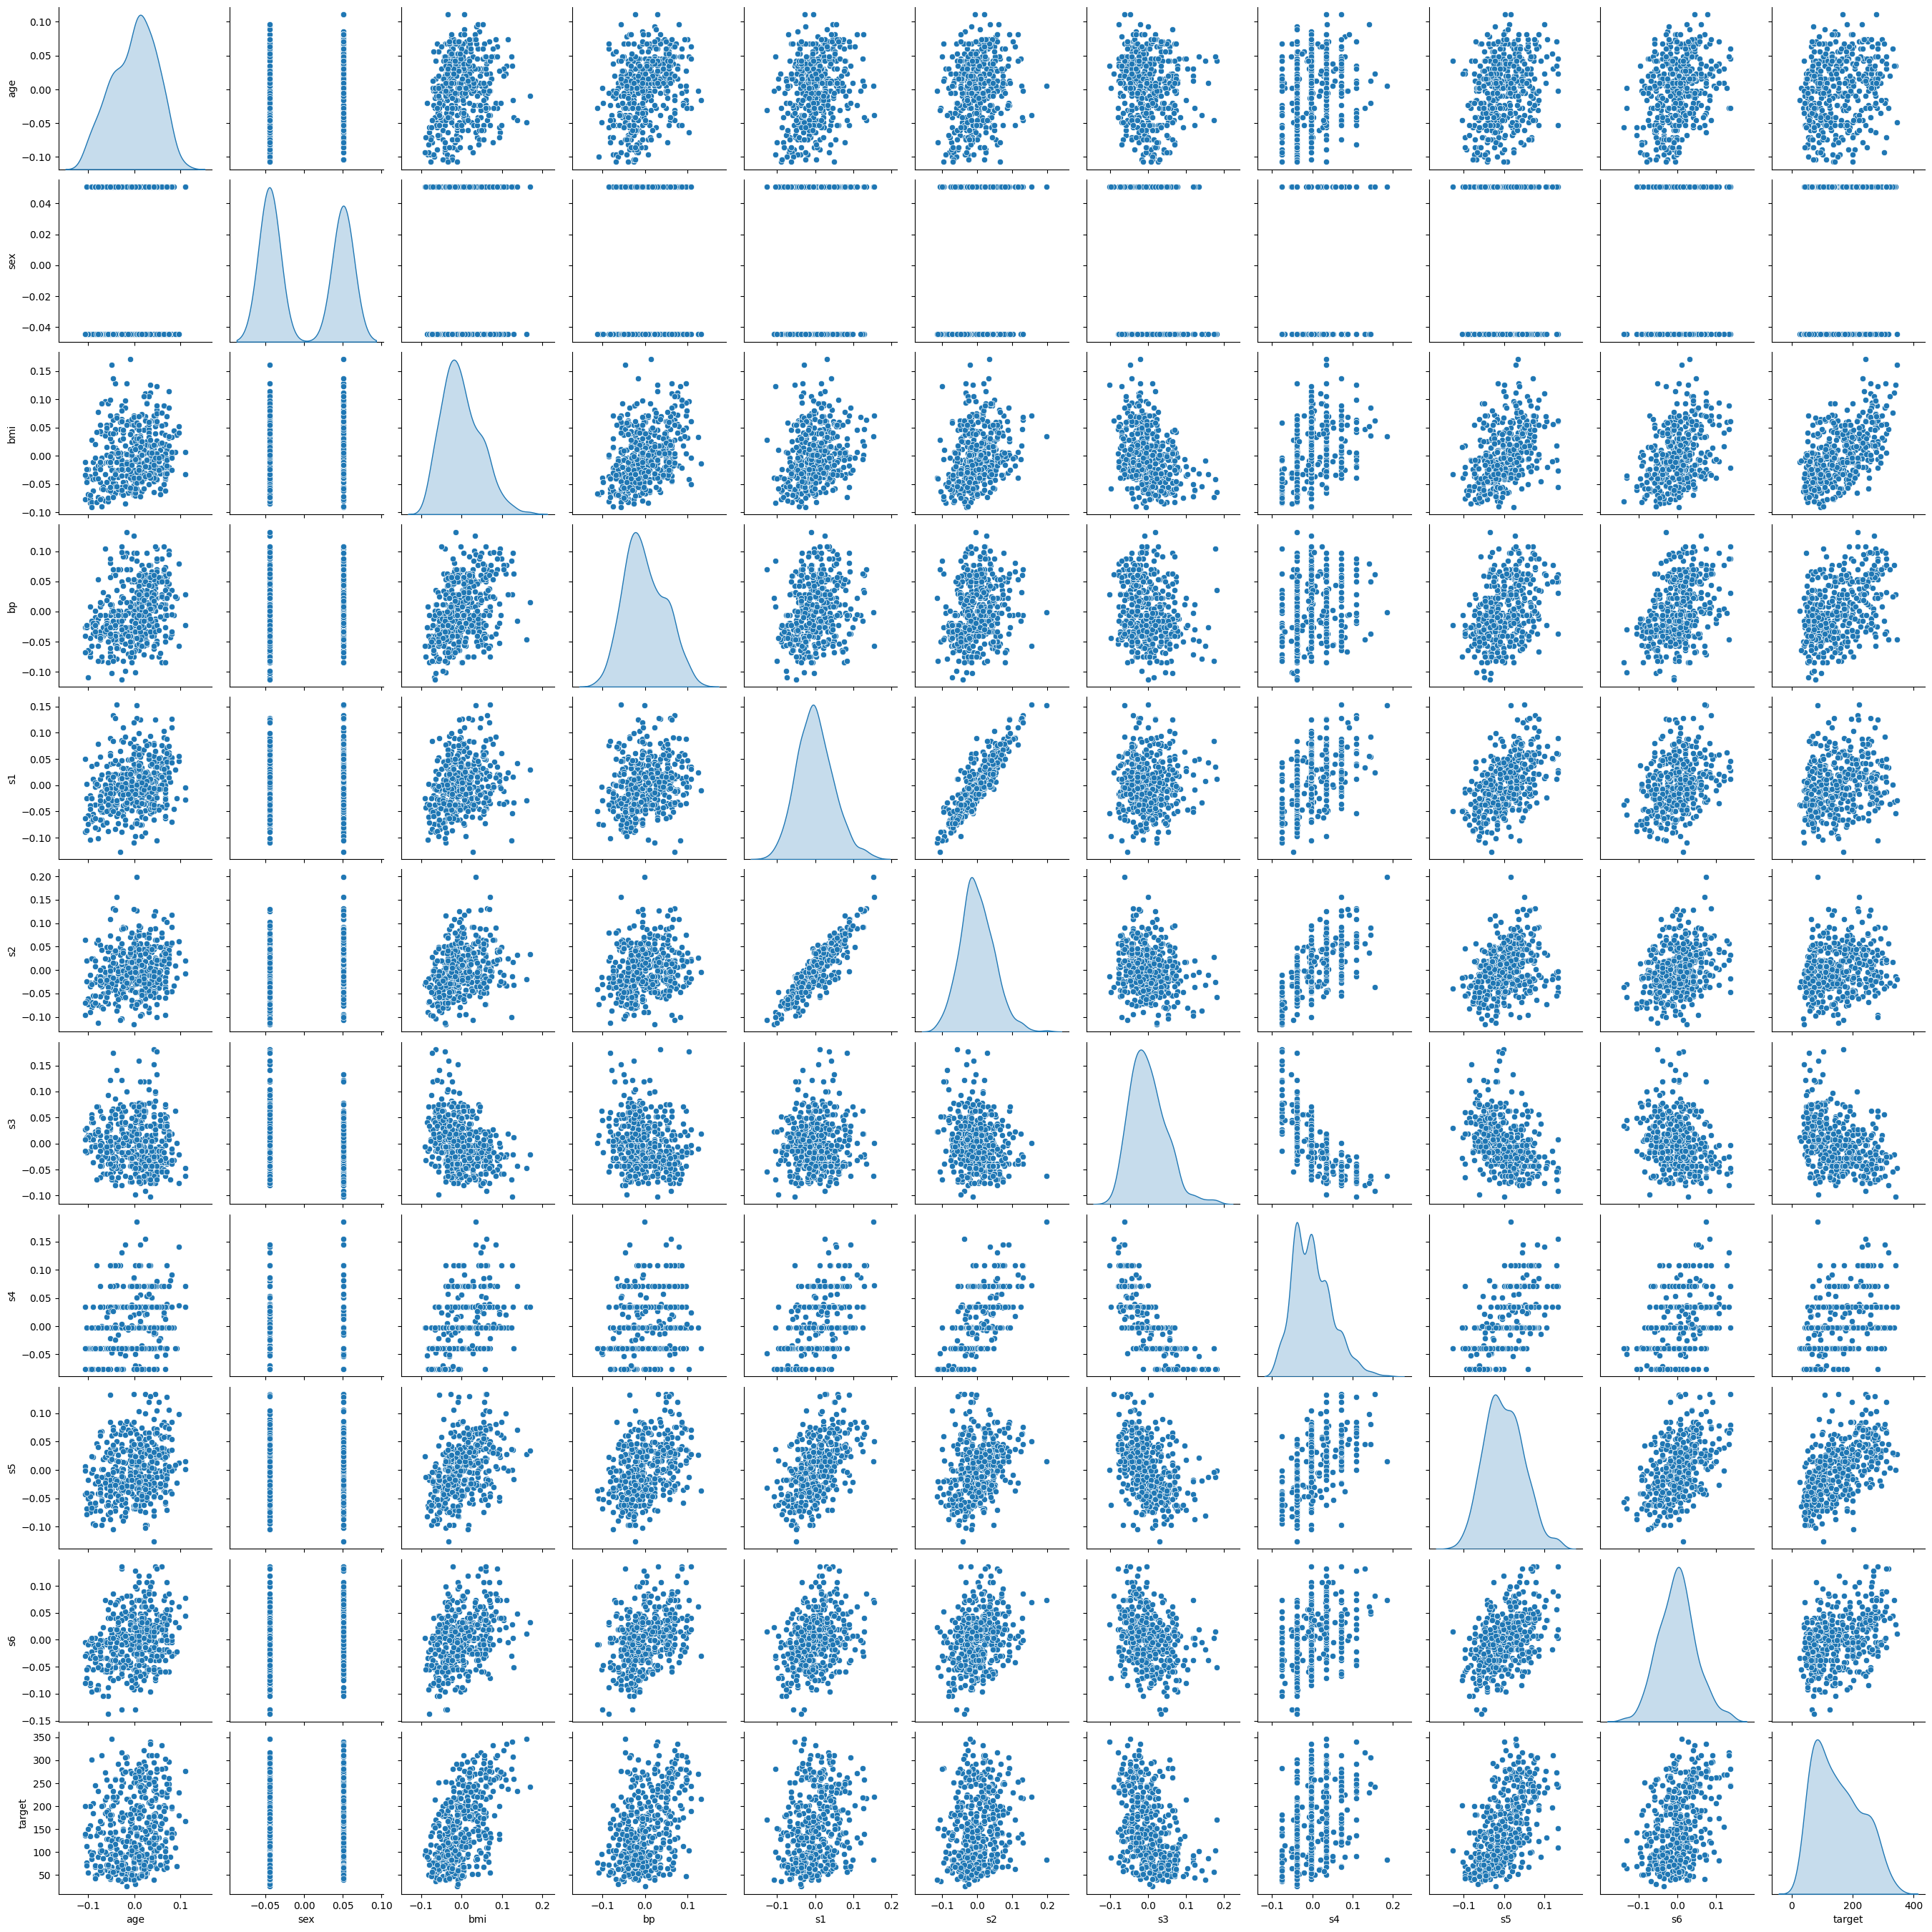

In [10]:
# Pairplot con seaborn
sns.pairplot(df,diag_kind="kde")
plt.show()


Vemos que la variable sexo es categórica, vamos a convertirla apropiadamente:

In [11]:
unique_sex_values = df['sex'].unique()
print(unique_sex_values)

# Crear un diccionario que asocie cada valor único con una etiqueta categórica
sex_mapping = {unique_sex_values[0]: 'Femenino', unique_sex_values[1]: 'Masculino'}


# Convertir la variable 'sex' en categórica
df['sex'] = df['sex'].map(sex_mapping)

# Verificar los cambios
print(df['sex'].unique())


[ 0.05068012 -0.04464164]
['Femenino' 'Masculino']


In [12]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,Femenino,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,Masculino,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,Femenino,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,Masculino,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,Masculino,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [13]:
df['sex'] = df['sex'].astype('category')

In [14]:
from scipy.stats import skew, kurtosis


# Calculando la asimetría y la curtosis solo para las variables numéricas
for column in df.columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        skewness = skew(df[column])
        kurt = kurtosis(df[column])
        print(f"{column}:\nAsimetría: {skewness}\nCurtosis: {kurt}\n")
    else:
        print(f"{column} es una variable categórica y se ha omitido del análisis.\n")


age:
Asimetría: -0.23059556012398927
Curtosis: -0.6771986900987508

sex es una variable categórica y se ha omitido del análisis.

bmi:
Asimetría: 0.5961166556214368
Curtosis: 0.08047812866813064

bp:
Asimetría: 0.28967103827590446
Curtosis: -0.5403332293804954

s1:
Asimetría: 0.3768238227280956
Curtosis: 0.2167770625244283

s2:
Asimetría: 0.4351087583570202
Curtosis: 0.5810556912433786

s3:
Asimetría: 0.7965401530972942
Curtosis: 0.9568955290670442

s4:
Asimetría: 0.7328756796573327
Curtosis: 0.42584638305986955

s5:
Asimetría: 0.2907626799653419
Curtosis: -0.14639566230288814

s6:
Asimetría: 0.20721035056151146
Curtosis: 0.22070114138631514

target:
Asimetría: 0.43906639932477265
Curtosis: -0.8866436055681386



La asimetría (skewness) y la curtosis son dos estadísticas que describen la forma de una distribución:

### Asimetría (Skewness):
- **Cerca de 0**: La distribución es aproximadamente simétrica.
- **Mayor que 0**: La distribución tiene una cola más larga hacia la derecha (asimetría positiva).
- **Menor que 0**: La distribución tiene una cola más larga hacia la izquierda (asimetría negativa).

### Curtosis:
- **Cerca de 0**: La distribución tiene una forma similar a una distribución normal en términos de colas y picos.
- **Mayor que 0**: La distribución tiene colas más pesadas y un pico más agudo que una distribución normal (leptocúrtica).
- **Menor que 0**: La distribución tiene colas más ligeras y un pico más plano que una distribución normal (platicúrtica).

### Interpretación de tus resultados:
- **bmi**: Ligeramente asimétrica a la derecha. Distribución aproximadamente normal en términos de curtosis.
- **bp**: Ligeramente asimétrica a la derecha. Ligeramente platicúrtica.
- **s1**: Ligeramente asimétrica a la derecha. Distribución aproximadamente normal en términos de curtosis.
- **s2**: Ligeramente asimétrica a la derecha. Ligeramente leptocúrtica.
- **s3**: Moderadamente asimétrica a la derecha. Moderadamente leptocúrtica.
- **s4**: Moderadamente asimétrica a la derecha. Ligeramente leptocúrtica.
- **s5**: Ligeramente asimétrica a la derecha. Ligeramente platicúrtica.
- **s6**: Ligeramente asimétrica a la derecha. Distribución aproximadamente normal en términos de curtosis.
- **target**: Ligeramente asimétrica a la derecha. Moderadamente platicúrtica.

En general, tus variables tienen asimetría positiva (cola a la derecha), y la mayoría de ellas tienen una forma aproximadamente normal en términos de curtosis, aunque algunas son ligeramente o moderadamente leptocúrticas o platicúrticas.

<ipython-input-15-4d74ea36b203>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')


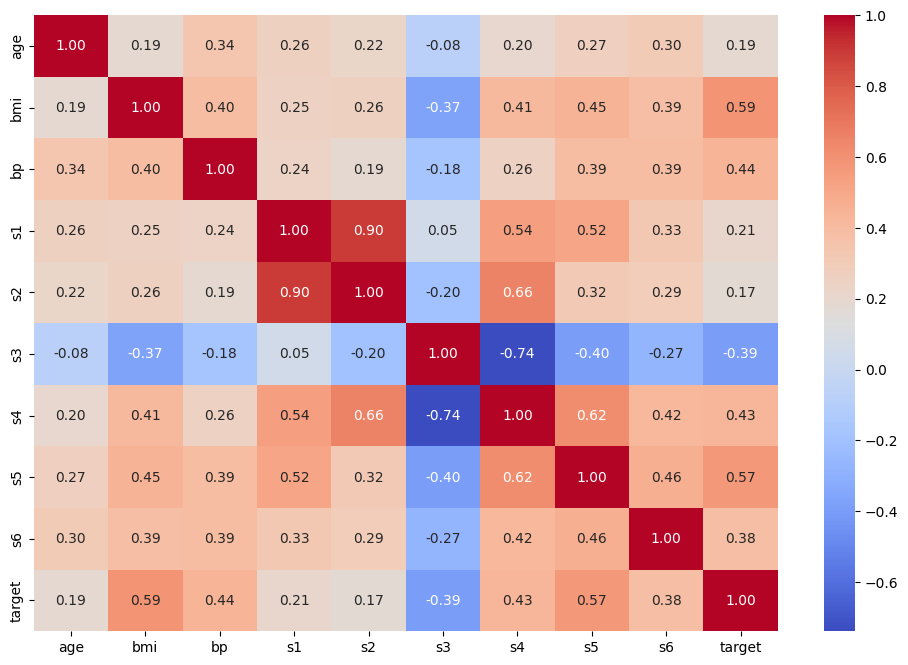

In [15]:
# Mapa de calor de la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


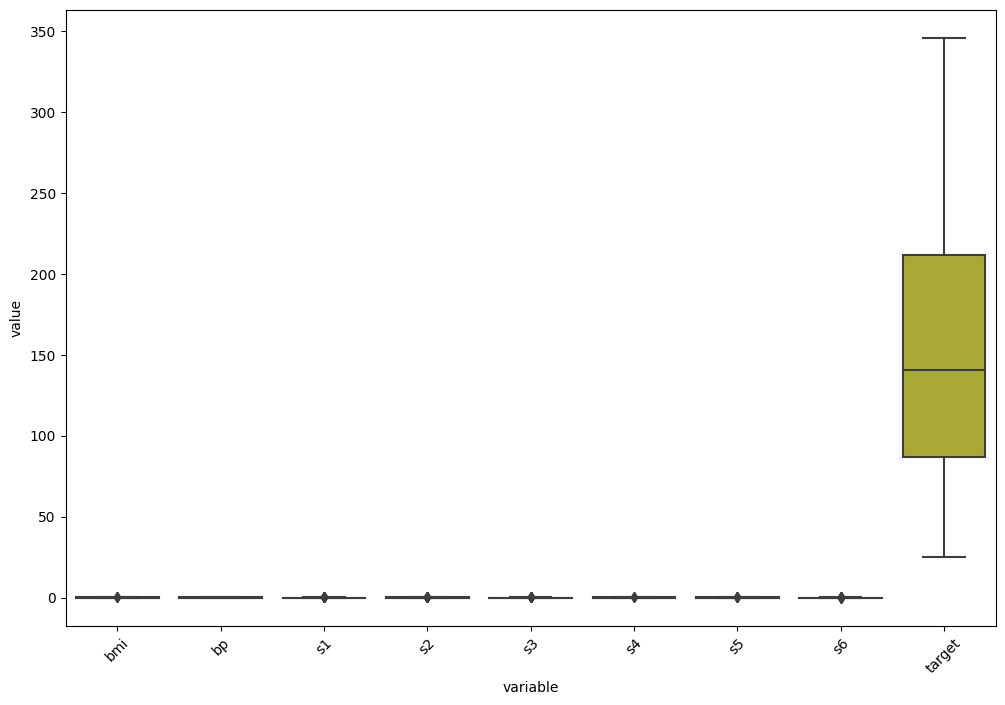

In [16]:
# Seleccionar solo las columnas numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Lista de columnas que quieres incluir en el boxplot
columns_to_include = [col for col in df_numeric.columns if col != 'age']

# Seleccionar solo las columnas deseadas
df_selected = df_numeric[columns_to_include]

# Derretir el DataFrame
df_melted = pd.melt(df_selected)

# Crear el boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x="variable", y="value", data=df_melted)
plt.xticks(rotation=45)
plt.show()




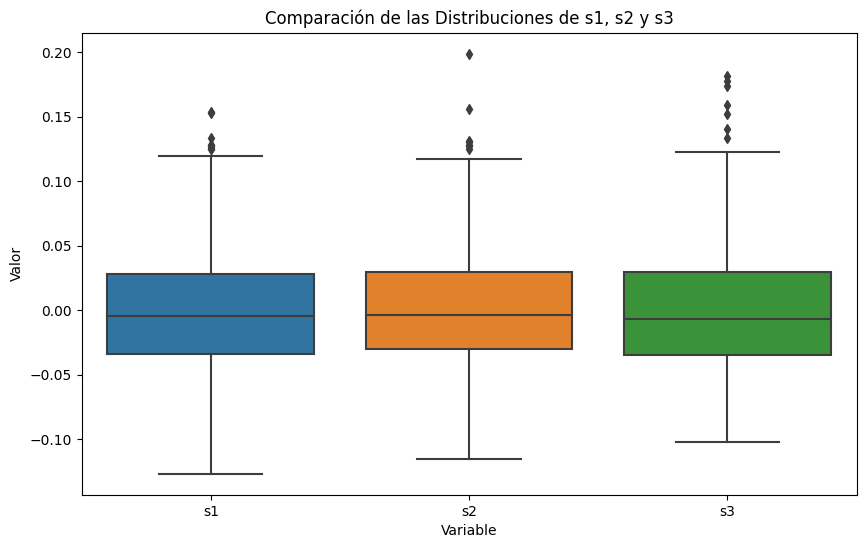

In [17]:
# Primero, debes fundir tu DataFrame para que Seaborn pueda interpretarlo correctamente
df_melted = df.melt(value_vars=['s1', 's2', 's3'])

# Ahora, puedes crear el diagrama de caja
plt.figure(figsize=(10, 6))
sns.boxplot(x='variable', y='value', data=df_melted)
plt.title('Comparación de las Distribuciones de s1, s2 y s3')
plt.xlabel('Variable')
plt.ylabel('Valor')
plt.show()

Podemos probar si la media de una de las variables es igual a un valor específico. Por ejemplo, probemos si la media del índice de masa corporal (BMI) es igual a 0 (que es el valor medio estandarizado en este conjunto de datos).

In [18]:
t_stat, p_value = stats.ttest_1samp(df['bmi'], 0)
print('Prueba T para una muestra - BMI')
print('T-statistic:', t_stat)
print('P-value:', p_value)
print('\n')

Prueba T para una muestra - BMI
T-statistic: -9.914159661291137e-14
P-value: 0.999999999999921




Podemos comparar las medias de dos grupos independientes. Por ejemplo, comparemos las medias de la variable 'target' entre hombres y mujeres.

In [19]:
t_stat, p_value = stats.ttest_ind(df[df['sex'] == 'Femenino']['target'], df[df['sex'] == 'Masculino']['target'])
print('Prueba T para dos muestras independientes - Target por Sexo')
print('T-statistic:', t_stat)
print('P-value:', p_value)
print('\n')


Prueba T para dos muestras independientes - Target por Sexo
T-statistic: 0.9041147550244715
P-value: 0.3664292946519826




Para evaluar diferencias en proporciones, primero necesitamos datos categóricos. Podemos convertir una variable continua en categórica. Por ejemplo, categorizamos la variable 'target' en 'alto' y 'bajo' y comparamos las proporciones entre hombres y mujeres.

In [20]:
from statsmodels.stats.proportion import proportions_ztest

# Crear una nueva columna categorizando 'target'
df['target_high'] = df['target'] > df['target'].median()

# Contar cuántos hombres y mujeres tienen un nivel alto de 'target'
high_target_men = df[(df['sex'] == 'Masculino') & (df['target_high'])].shape[0]
high_target_women = df[(df['sex'] == 'Femenino') & (df['target_high'])].shape[0]



# Contar el total de hombres y mujeres
total_men = df[df['sex'] == 'Masculino'].shape[0]
total_women = df[df['sex'] == 'Femenino'].shape[0]

# Realizar la prueba Z de proporciones
stat, p_value = proportions_ztest([high_target_men, high_target_women], [total_men, total_women])

print('Prueba Z para Proporciones - Target Alto por Sexo')
print('Z-statistic:', stat)
print('P-value:', p_value)


Prueba Z para Proporciones - Target Alto por Sexo
Z-statistic: -0.09532175524680796
P-value: 0.9240592631433202


In [21]:
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,target_high
0,0.038076,Femenino,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,True
1,-0.001882,Masculino,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,False
2,0.085299,Femenino,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0,True
3,-0.089063,Masculino,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,True
4,0.005383,Masculino,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0,False
